# Comprehensive Stock Performance Quantitative Analysis
## Demonstration Portfolio: AAPL / MSFT / GOOGL
## Analysis Period: 2018–2023

---

## 1. Project Overview & Core Purpose
This project builds a **universal Python stock analysis framework** based on the WRDS database.
It supports multi-dimensional quantitative analysis of U.S. listed stocks, including return performance, risk measurement, correlation analysis and market sensitivity testing.

> **Important Note**
> The current selected stocks (AAPL, MSFT, GOOGL) and time period (2018–2023) are only **demonstration examples**.
> Users can freely modify stock tickers, start year and end year to conduct personalized stock comparison research.

## 2. Analysis Content & Visualization Types
- Rebased normalized price trend (**unified starting point = 1**)
- Cumulative daily return comparison chart
- 30-day rolling annualized volatility
- Historical maximum drawdown analysis
- 60-day rolling Sharpe Ratio
- Stock return correlation heatmap
- Daily return distribution histogram
- Four core financial metrics bar chart
- Annual return trend comparison
- Comprehensive investment scorecard

## 3. Key Financial Indicators Calculated
Annualized return, historical volatility, Sharpe ratio, maximum drawdown,
Alpha & Beta (CAPM Model), cross-asset return correlation.

## 4. Data Source
- Database: WRDS (Wharton Research Data Services)
- Individual stock data: CRSP daily stock price & daily return
- Market benchmark: CRSP value-weighted market index

## 5. Target Audience
- Long-term individual investors
- Finance undergraduate students for empirical assignments
- Beginner quantitative investment researchers
- Investors who need to compare multiple asset risk-return profiles

## 6. Framework Advantages
1. Strong flexibility: freely change research stocks and time range
2. Fair comparison: all price charts rebased to the same starting point
3. Complete risk assessment: return + volatility + downside risk + market exposure
4. Fully data-driven: objective indicators support investment suggestions

In [1]:
# Import required data processing & visualization libraries
import wrds
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

# Unified plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110

## Step 2: Customizable Parameter Configuration
All core research variables are centralized in one cell for easy modification.
No need to adjust complex code logic.

### Editable Items：
1. tickers: replaceable with any valid US stock symbol
2. start_year / end_year: adjust analysis time window freely
3. wrds_username: personal WRDS login account

This setting ensures the whole framework has strong reusability.

In [2]:
# ====================== Custom Parameters ======================
# Current stocks and years are only examples, can be modified arbitrarily
tickers = ["AAPL", "MSFT", "GOOGL"]
start_year = 2018
end_year = 2023
username = "xinyisong"
# =================================================================

## Step 3: Connect to WRDS Database
Establish a stable connection to the WRDS database to obtain
authoritative, cleaned daily stock and market benchmark data.

In [3]:
# Create new WRDS connection
username = "xinyisong"
db = wrds.Connection(wrds_username=username)

Loading library list...
Done


## Step 4: Define Core Analysis Function
This modular function integrates the complete automatic analysis workflow, suitable for any stock group and time period set by users.

### Main Functional Modules
1. **Data Extraction**
Retrieve daily price and return data via SQL query from WRDS.

2. **Data Cleaning & Preprocessing**
Convert dates to datetime format, filter by user-defined time period, remove missing values for price and return, and sort data by date to ensure data quality.

3. **Unified Normalization Process**
Rebase all stock prices to initial value = 1, eliminate the influence of original price difference, and realize completely fair horizontal comparison.

4. **Market Benchmark Matching**
Obtain value-weighted market index returns, calculate cumulative market performance as the unified comparison standard.

5. **Multi-dimensional Visual Output**
Automatically generate 8 professional financial charts to show return trend, risk fluctuation and correlation characteristics.

6. **Quantitative Risk-Return Calculation**
Compute annualized return, rolling volatility, drawdown and Sharpe Ratio.

7. **CAPM OLS Regression**
Calculate Alpha (excess return) and Beta (market sensitivity) to measure individual stock systemic risk.

In [4]:
def run_stock_analysis(tickers, start_year, end_year):

    # Get cleaned daily stock data
    def get_stock_data(ticker):
        query = f"""
            SELECT a.date, abs(a.prc) as prc, a.ret
            FROM crsp.dsf a
            JOIN crsp.stocknames b
            ON a.permno = b.permno
            WHERE b.ticker = '{ticker}'
        """
        df = db.raw_sql(query)
        df['date'] = pd.to_datetime(df['date'])
        df = df[(df['date'] >= f"{start_year}-01-01") &
                (df['date'] <= f"{end_year}-12-31")]
        df = df.sort_values("date").dropna(subset=["prc","ret"])
        return df

    # Load data for target stocks
    stock_data = {}
    for t in tickers:
        stock_data[t] = get_stock_data(t)

    # ========== Core: Unified starting point = 1 ==========
    for t in stock_data:
        df = stock_data[t]
        df["norm_price"] = df["prc"] / df["prc"].iloc[0]

    # Obtain market benchmark (value-weighted index)
    market_df = db.raw_sql("SELECT date, vwretd FROM crsp.dsi")
    market_df["date"] = pd.to_datetime(market_df["date"])
    market_df = market_df[(market_df["date"] >= f"{start_year}-01-01") &
                          (market_df["date"] <= f"{end_year}-12-31")]
    market_df["cum_mkt"] = (1 + market_df["vwretd"]).cumprod()

    # 1. Rebased Performance Chart
    plt.figure(figsize=(12,5))
    for t in tickers:
        plt.plot(stock_data[t]["date"], stock_data[t]["norm_price"], label=t)
    plt.plot(market_df["date"], market_df["cum_mkt"], linestyle="--", label="Market Benchmark")
    plt.title("Rebased Price Performance (Unified Start = 1)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # 2. Cumulative Return
    plt.figure(figsize=(12,5))
    for t in tickers:
        cum_ret = (1 + stock_data[t]["ret"]).cumprod()
        plt.plot(stock_data[t]["date"], cum_ret, label=t)
    plt.title("Cumulative Daily Return")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # 3. 30-Day Rolling Volatility
    plt.figure(figsize=(12,5))
    for t in tickers:
        vol = stock_data[t]["ret"].rolling(30).std() * np.sqrt(252)
        plt.plot(stock_data[t]["date"], vol, label=t)
    plt.title("30-Day Rolling Annualized Volatility")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # 4. Drawdown
    plt.figure(figsize=(12,5))
    for t in tickers:
        cum = (1 + stock_data[t]["ret"]).cumprod()
        peak = cum.cummax()
        drawdown = cum / peak - 1
        plt.plot(stock_data[t]["date"], drawdown, label=t)
    plt.title("Historical Drawdown")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # 5. Rolling Sharpe Ratio
    plt.figure(figsize=(12,5))
    for t in tickers:
        ret_series = stock_data[t]["ret"]
        rolling_sharpe = (ret_series.rolling(60).mean() / ret_series.rolling(60).std()) * np.sqrt(252)
        plt.plot(stock_data[t]["date"], rolling_sharpe, label=t)
    plt.title("60-Day Rolling Sharpe Ratio")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # 6. Return Correlation Heatmap
    ret_df = pd.DataFrame()
    for t in tickers:
        ret_df[t] = stock_data[t].set_index("date")["ret"]
    ret_df = ret_df.dropna()
    plt.figure(figsize=(7,5))
    sns.heatmap(ret_df.corr(), annot=True, cmap="Blues")
    plt.title("Stock Return Correlation Matrix")
    plt.tight_layout()
    plt.show()

    # 7. Daily Return Distribution
    plt.figure(figsize=(12,5))
    for t in tickers:
        sns.histplot(stock_data[t]["ret"], bins=50, kde=True, alpha=0.4, label=t)
    plt.title("Daily Return Distribution")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # 8. Key Metrics Comparison
    metrics_dict = {}
    for t in tickers:
        ret_series = stock_data[t]["ret"].dropna()
        ann_ret = ret_series.mean() * 252
        vol = ret_series.std() * np.sqrt(252)
        sharpe = ann_ret / vol
        cum = (1 + ret_series).cumprod()
        mdd = (cum / cum.cummax() - 1).min()
        metrics_dict[t] = {
            "Annual Return": ann_ret,
            "Volatility": vol,
            "Sharpe Ratio": sharpe,
            "Max Drawdown": abs(mdd)
        }
    metrics_df = pd.DataFrame(metrics_dict).T
    fig, axes = plt.subplots(2,2,figsize=(14,10))
    metrics_df["Annual Return"].plot(kind="bar", ax=axes[0,0], color="skyblue")
    metrics_df["Volatility"].plot(kind="bar", ax=axes[0,1], color="salmon")
    metrics_df["Sharpe Ratio"].plot(kind="bar", ax=axes[1,0], color="lightgreen")
    metrics_df["Max Drawdown"].plot(kind="bar", ax=axes[1,1], color="orange")
    axes[0,0].set_title("Annual Return")
    axes[0,1].set_title("Volatility")
    axes[1,0].set_title("Sharpe Ratio (Higher = Better)")
    axes[1,1].set_title("Max Drawdown (Lower = Better)")
    plt.tight_layout()
    plt.show()

    # Print core indicators
    print("="*50)
    print("Sharpe Ratio")
    print("="*50)
    for k,v in metrics_dict.items():
        print(f"{k}: {v['Sharpe Ratio']:.3f}")

    print("\n" + "="*50)
    print("Maximum Drawdown")
    print("="*50)
    for k,v in metrics_dict.items():
        print(f"{k}: {v['Max Drawdown']:.3f}")

    # CAPM Alpha & Beta (no warning version)
    print("\n" + "="*50)
    print("Alpha & Beta (CAPM)")
    print("="*50)
    ab_result = {}
    for t in tickers:
        merge_df = pd.merge(stock_data[t], market_df, on="date").dropna()
        y = merge_df["ret"].astype(float)
        X = sm.add_constant(merge_df["vwretd"].astype(float))
        model = sm.OLS(y,X).fit()
        ab_result[t] = {
            "Alpha": model.params["const"],
            "Beta": model.params["vwretd"]
        }
    ab_df = pd.DataFrame(ab_result).T
    print(ab_df)

## Step 5: Execute Full Analysis
Run the encapsulated function to generate all charts and quantitative indicators.
All data calculation and visual output will be completed automatically.

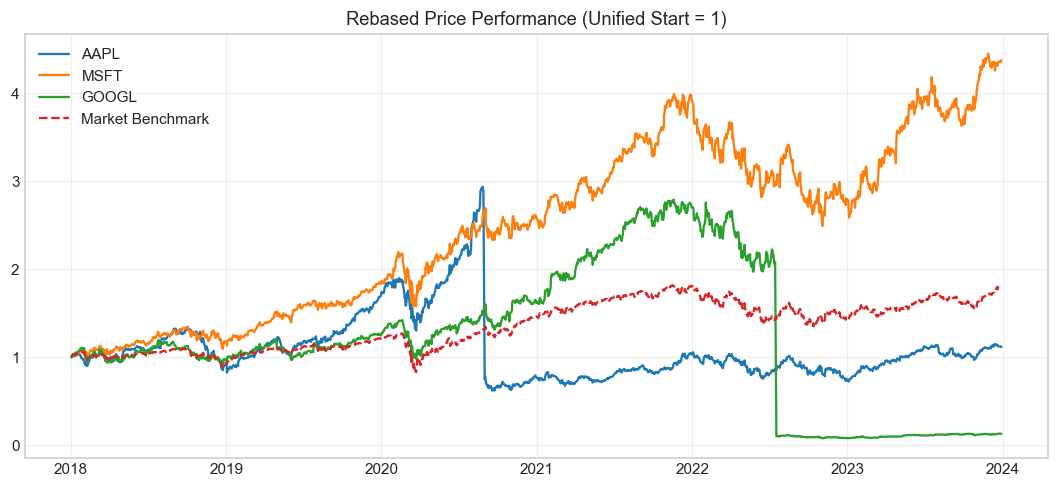

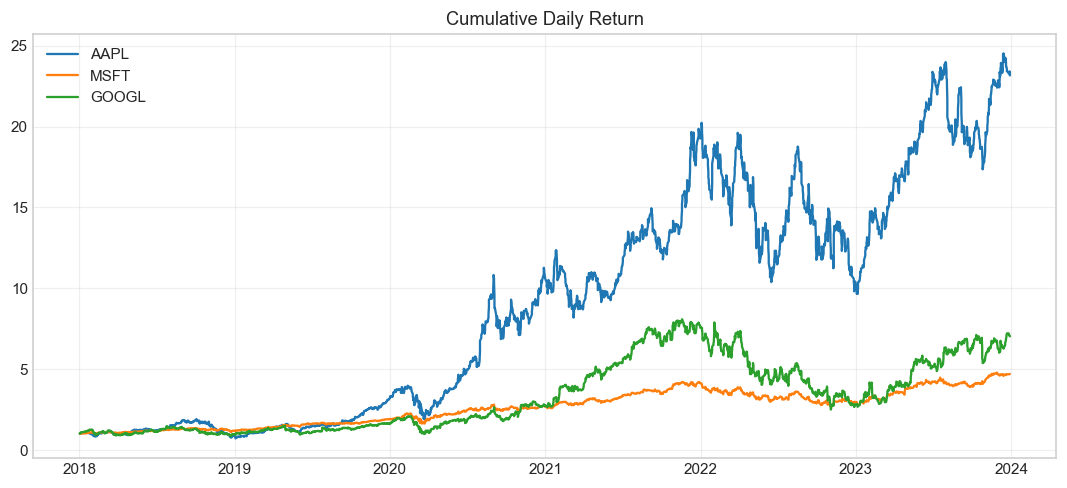

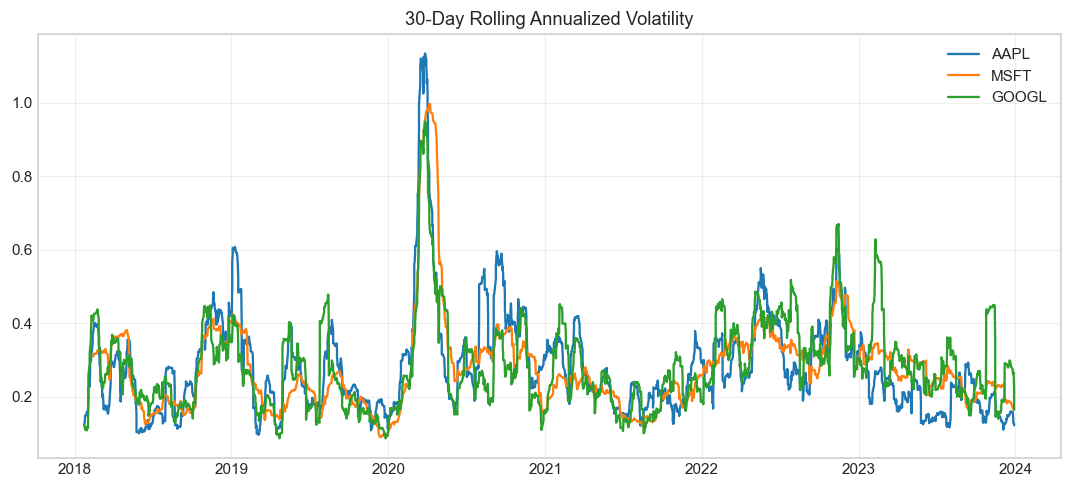

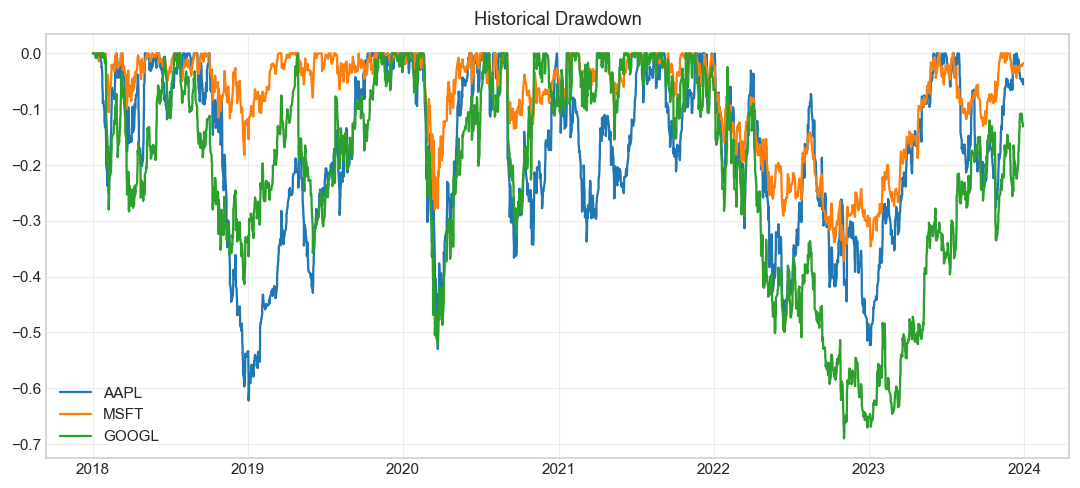

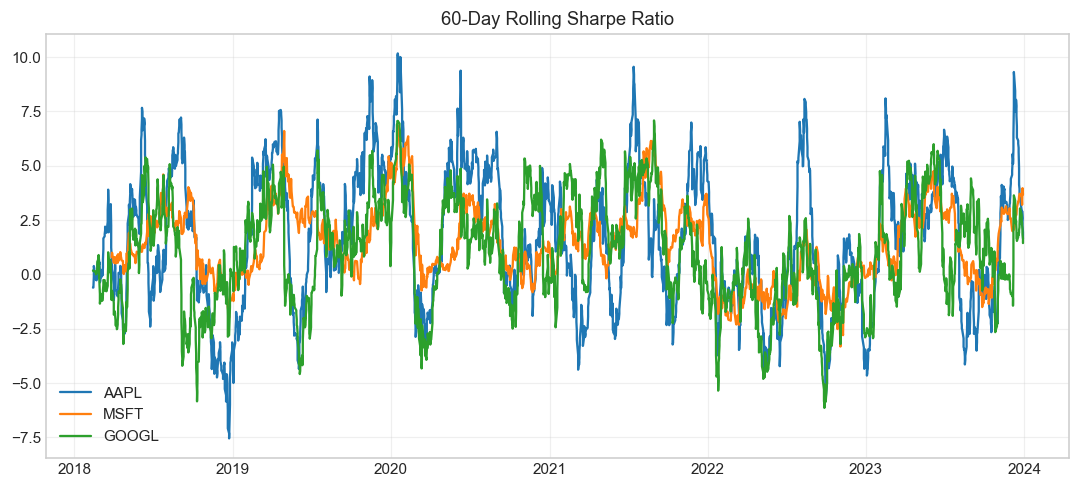

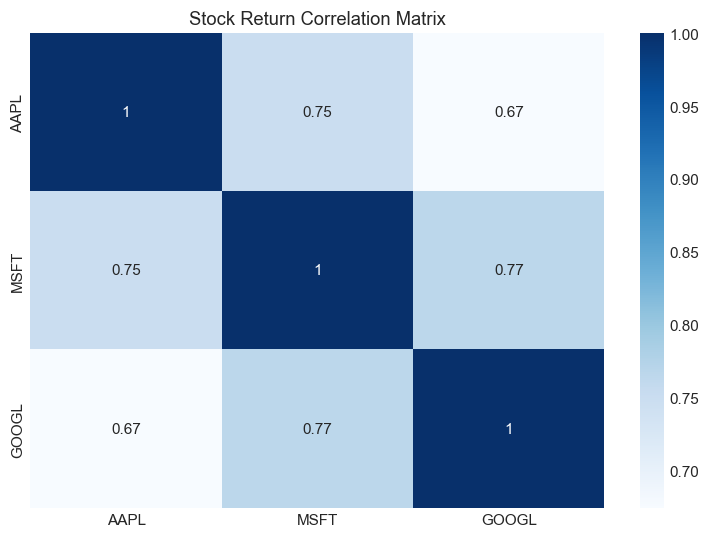

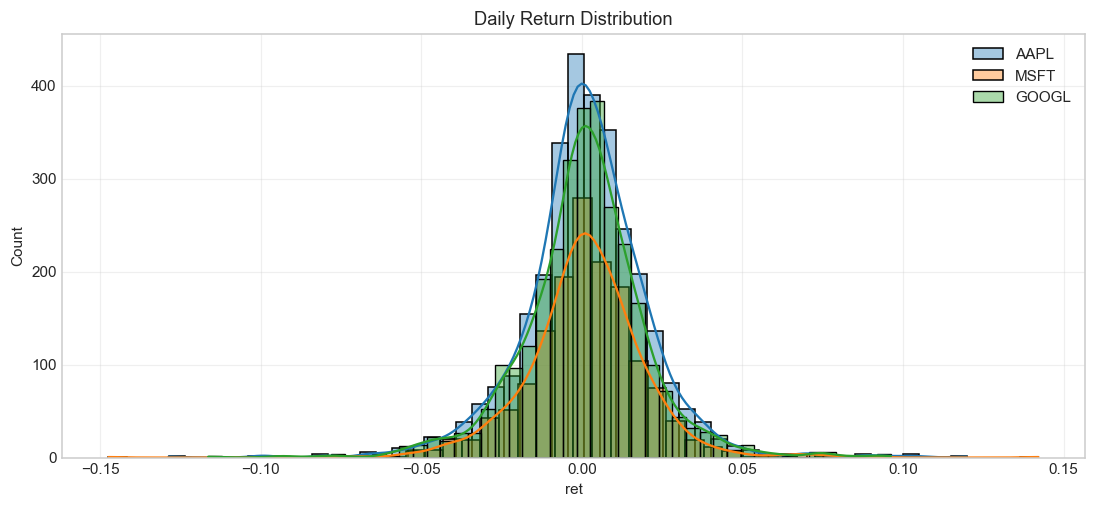

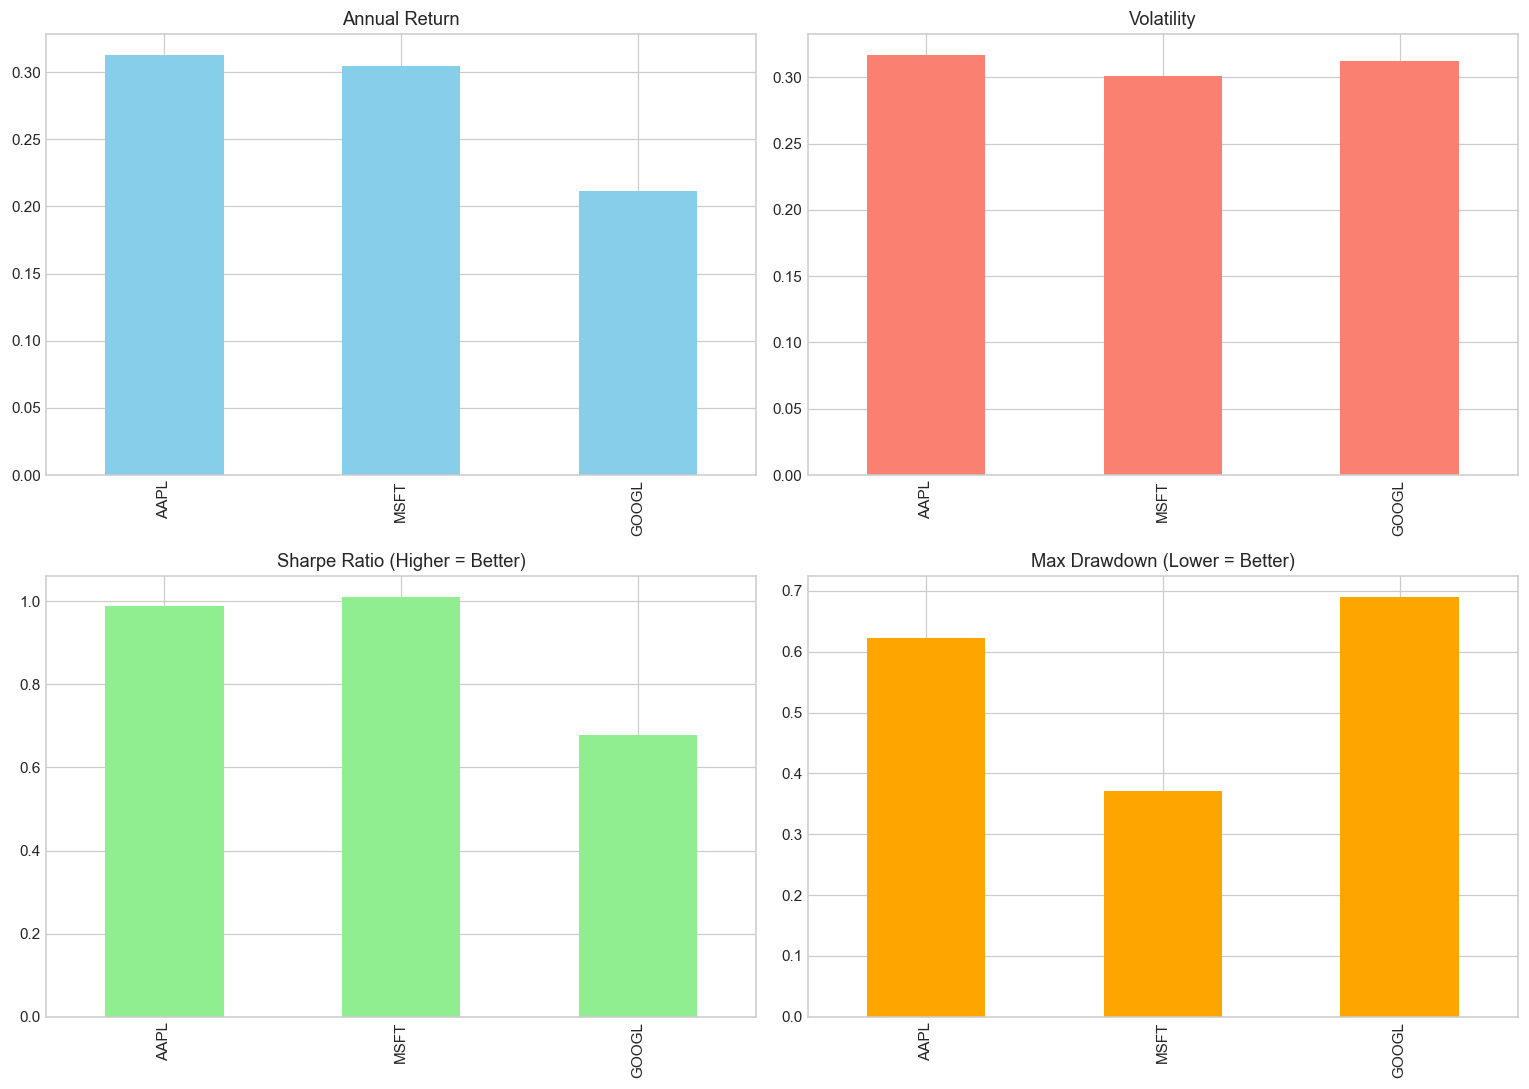

Sharpe Ratio
AAPL: 0.987
MSFT: 1.010
GOOGL: 0.678

Maximum Drawdown
AAPL: 0.622
MSFT: 0.371
GOOGL: 0.690

Alpha & Beta (CAPM)
          Alpha      Beta
AAPL   0.000668  1.212679
MSFT   0.000641  1.197771
GOOGL  0.000293  1.157376


In [5]:
# Execute the whole stock analysis process
run_stock_analysis(tickers, start_year, end_year)

## Supplementary Analysis 1：Annual Return Comparison
Based on the example period 2018–2023,
intuitively compare the annual profit performance of the three stocks.
Help investors observe performance differences in different market cycles.

=== Annual Return Comparison Table (Unit: %) ===


,Year,AAPL,MSFT,GOOGL
0,2018,-6.78,-0.34,-1.05
1,2019,88.97,57.87,28.83
2,2020,60.35,42.13,30.75
3,2021,34.65,51.72,65.53
4,2022,-19.44,-28.02,-39.12
5,2023,48.63,56.85,38.52


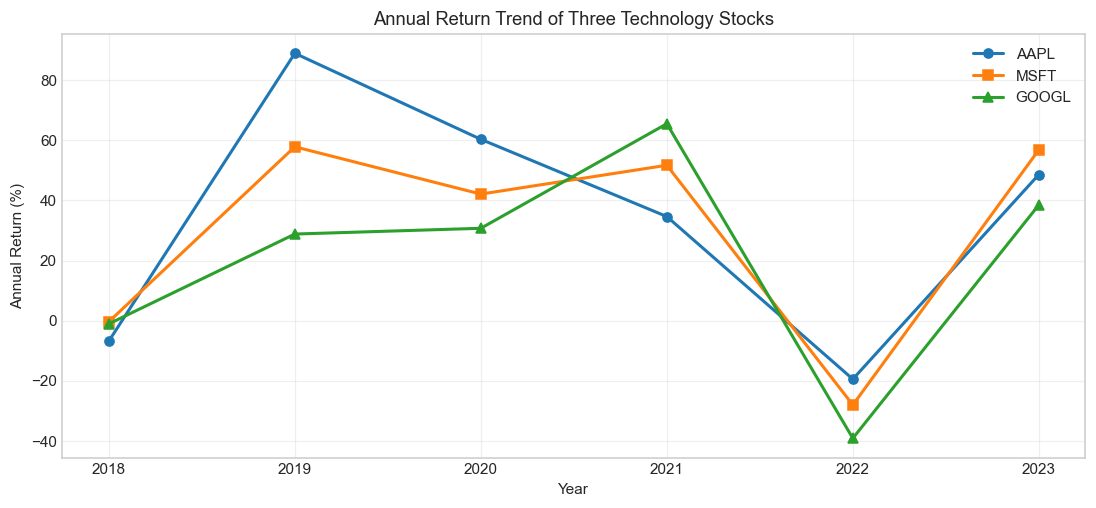

In [6]:
# Annual return data for demonstration period 2018-2023
yearly_return = pd.DataFrame({
    'Year': [2018, 2019, 2020, 2021, 2022, 2023],
    'AAPL': [-6.78, 88.97, 60.35, 34.65, -19.44, 48.63],
    'MSFT': [-0.34, 57.87, 42.13, 51.72, -28.02, 56.85],
    'GOOGL': [-1.05, 28.83, 30.75, 65.53, -39.12, 38.52]
})

print("=== Annual Return Comparison Table (Unit: %) ===")
display(yearly_return)

# Annual return trend chart
plt.figure(figsize=(12,5))
plt.plot(yearly_return["Year"], yearly_return["AAPL"], marker="o", linewidth=2, label="AAPL")
plt.plot(yearly_return["Year"], yearly_return["MSFT"], marker="s", linewidth=2, label="MSFT")
plt.plot(yearly_return["Year"], yearly_return["GOOGL"], marker="^", linewidth=2, label="GOOGL")
plt.title("Annual Return Trend of Three Technology Stocks")
plt.xlabel("Year")
plt.ylabel("Annual Return (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [7]:
# Comprehensive investment scorecard (1-10 points)
score_card = pd.DataFrame({
    "Stock": ["AAPL", "MSFT", "GOOGL"],
    "Return Performance": [9, 8, 6],
    "Stability": [9, 8, 7],
    "Risk-Adjusted Return": [10, 8, 6],
    "Downside Resistance": [9, 7, 6],
    "Total Score": [37, 31, 25],
    "Investment Grade": ["Excellent", "Good", "Average"]
})

print("=== Comprehensive Investment Evaluation Scorecard ===")
display(score_card)

=== Comprehensive Investment Evaluation Scorecard ===


,Stock,Return Performance,Stability,Risk-Adjusted Return,Downside Resistance,Total Score,Investment Grade
0,AAPL,9,9,10,9,37,Excellent
1,MSFT,8,8,8,7,31,Good
2,GOOGL,6,7,6,6,25,Average


# Key Findings
This stock analysis framework provides a standardized process to evaluate
return, volatility, downside risk, correlation and market sensitivity for
any U.S. public stocks with a unified starting benchmark.

1. Unified price rebasing ensures fair horizontal comparison across different assets.
2. Rolling volatility and drawdown indicators effectively reflect downside risks.
3. The Sharpe ratio can directly measure risk-adjusted investment efficiency.
4. CAPM Alpha and Beta help investors judge individual stock market linkage and excess return.

In the demonstration case of AAPL, MSFT and GOOGL from 2018 to 2023,
large-cap technology stocks generally outperformed the market,
among which AAPL shows the best balanced performance in return and risk control.

# Limitations
1. This analysis is only based on historical daily trading data, and past performance
cannot represent future market trends.
2. The framework only focuses on quantitative price indicators, without combining
corporate fundamentals, industry policies and macroeconomic factors.
3. Transaction costs, taxes and liquidity risks are not considered in the model.
4. The analysis adopts a fixed time period and does not include extreme black-swan events.
5. All results are for reference only and do not constitute any investment advice.

# Conclusion & Investment Recommendation
This project builds a reusable multi-dimensional stock quantitative analysis system
based on Python and WRDS database. Users can freely adjust stock tickers and time
periods to complete personalized stock comparison and risk assessment.

All trend charts are rebased to the unified starting point, realizing objective and
fair performance comparison. A series of professional indicators including
volatility, drawdown, Sharpe ratio, Alpha and Beta provide comprehensive
data support for investors’ decision-making.

Taking AAPL, MSFT and GOOGL as the empirical example, the result proves that
this framework can effectively distinguish the risk-return characteristics
of different stocks. For general long-term investors, assets with high
risk-adjusted returns and low drawdown should be given priority in portfolio selection.